# Load Data & imports

In [49]:
# Imports und small helper: prüfe, ob wichtige Pakete vorhanden sind und zeige eine kurze Nachricht,
# falls etwas fehlt, installiere es in deiner Virtualenv (zsh):
# pip install ipywidgets scikit-image matplotlib imageio
%load_ext autoreload
%autoreload 2

import pickle
import gzip
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
import ipywidgets as widgets
from ipywidgets import IntSlider, FloatSlider, VBox
import os

print('Imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK


### Helper functions

In [50]:
def load_zipped_pickle(filename):
    with gzip.open(filename, 'rb') as f:
        loaded_object = pickle.load(f)
        return loaded_object

In [51]:
def save_zipped_pickle(obj, filename):
    with gzip.open(filename, 'wb') as f:
        pickle.dump(obj, f, 2)

Example format of sample: { 'name': 'AC8ASN45B9', 'video': array([...], dtype='uint8'), 'box': array([...], dtype='bool'), 'label': array([...], dtype='bool'), 'frames': [41, 65, 167], 'dataset': 'amateur' }

In [52]:
# Pfad zu train.pkl anpassen falls nötig
pkl_path = './data/raw/train.pkl'
if not os.path.exists(pkl_path):
    raise FileNotFoundError(f'{pkl_path} nicht gefunden im aktuellen Verzeichnis: {os.getcwd()}')

data = load_zipped_pickle(pkl_path)

print('Number of samples:', len(data))

# Inspect a few samples (up to 3)
for i, sample in enumerate(data[:3]):
    print(f'Sample {i} name:', sample.get('name'))
    vid = sample.get('video')
    lab = sample.get('label')
    box = sample.get('box')
    print('  video: dtype=', getattr(vid, 'dtype', None), ' shape=', getattr(vid, 'shape', None))
    print('  label: dtype=', getattr(lab, 'dtype', None), ' shape=', getattr(lab, 'shape', None))
    print('  box:   dtype=', getattr(box, 'dtype', None), ' shape=', getattr(box, 'shape', None))
    print('  frames:', sample.get('frames'))

Number of samples: 65
Sample 0 name: D47OR19ANJ
  video: dtype= uint8  shape= (112, 112, 334)
  label: dtype= bool  shape= (112, 112, 334)
  box:   dtype= bool  shape= (112, 112)
  frames: [15, 59, 143]
Sample 1 name: IMNKTJV3OI
  video: dtype= uint8  shape= (112, 112, 177)
  label: dtype= bool  shape= (112, 112, 177)
  box:   dtype= bool  shape= (112, 112)
  frames: [2, 47, 79]
Sample 2 name: YSCCEISFRH
  video: dtype= uint8  shape= (112, 112, 195)
  label: dtype= bool  shape= (112, 112, 195)
  box:   dtype= bool  shape= (112, 112)
  frames: [18, 83, 131]


# Visualization of Data

In [68]:
# Interaktiver Viewer mit ipywidgets + matplotlib
# Funktion zum Anzeigen eines Frames mit Masken-Overlay und Konturen
def show_frame(sample_idx=0, t=0, alpha=0.5, downsample=1):
    sample = data[sample_idx]
    video = sample['video']  # video shape (H, W, T)
    label = sample.get('label')
    box = sample.get('box')

    # handle possible color channels
    img = video[:, :, t]

    mask = None
    if label is not None:
        mask = label[:, :, t].astype(bool)

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')

    # mask overlay (red) — uses per-pixel RGBA so alpha only affects mask area
    if mask is not None:
        h, w = mask.shape
        rgba = np.zeros((h, w, 4), dtype=np.float32)
        rgba[..., 0] = 1.0                      # red channel
        rgba[..., 3] = mask.astype(float) * alpha  # alpha channel only where mask True
        plt.imshow(rgba, interpolation='nearest')
        # draw contours for better visibility
        try:
            contours = measure.find_contours(mask.astype(np.uint8), 0.5)
            for contour in contours:
                plt.plot(contour[:, 1], contour[:, 0], linewidth=1.2, color='yellow')
        except Exception:
            # falls find_contours fehlschlägt, ignoriere
            pass

    # box overlay (green) — assume box is a 2D bool mask (H, W)
    if box is not None:
        b = np.asarray(box).astype(bool)
        # make overlay mask
        rgba_box = np.zeros((b.shape[0], b.shape[1], 4), dtype=np.float32)
        rgba_box[..., 1] = 1.0  # green channel
        rgba_box[..., 3] = b.astype(float) * alpha / 2
        plt.imshow(rgba_box, interpolation='nearest')

    plt.title(f"{sample.get('name', 'sample')} frame {t}. Dataset: {sample['dataset']}")
    plt.axis('off')
    plt.show()

# Widgets: sample index, frame index (aktualisiert sich beim Wechsel des Samples), alpha
n_samples = len(data)
sample_slider = IntSlider(min=0, max=n_samples-1, value=0, description='sample')
# initial max für frame von sample 0
initial_max_frame = data[0]['video'].shape[2] - 1
frame_slider = IntSlider(min=0, max=initial_max_frame, value=0, description='frame')
alpha_slider = FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5, description='alpha')
downsample_slider = IntSlider(min=1, max=8, step=1, value=1, description='down')

def _on_sample_change(change):
    if change['name'] == 'value':
        s = change['new']
        maxf = data[s]['video'].shape[2] - 1
        frame_slider.max = maxf
        frame_slider.value = 0

sample_slider.observe(_on_sample_change, names='value')

out = widgets.interactive_output(show_frame, {'sample_idx': sample_slider, 't': frame_slider, 'alpha': alpha_slider, 'downsample': downsample_slider})
ui = VBox([sample_slider, frame_slider, alpha_slider, downsample_slider])
display(ui, out)


Output()

# Implement UNet Architecture

In [54]:
# PyTorch UNet implementation + Dice loss + small training/eval scaffolding
# Install instructions (if needed): pip install torch torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List


class DoubleConv(nn.Module):
    """(conv => BN => ReLU) * 2"""
    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        if not mid_ch:
            mid_ch = out_ch
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv. Uses bilinear upsampling by default.

    NOTE: fixed channel arithmetic: after upsampling x1 (in_ch channels) we concatenate
    the encoder feature x2 (out_ch channels) -> conv input channels = in_ch + out_ch
    """
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        self.bilinear = bilinear
        if bilinear:
            # simple upsample; channel count of x1 remains in_ch
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            conv_in = in_ch + out_ch
            self.conv = DoubleConv(conv_in, out_ch, mid_ch=conv_in // 2)
        else:
            # ConvTranspose2d that halves channels of x1 to match expected concat shape
            # Here we make x1 -> in_ch//2 so that after concat with x2 (out_ch) we get in_ch//2 + out_ch
            # but to keep it simple set transpose to produce out_ch channels then conv gets out_ch + out_ch
            self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
            conv_in = out_ch + out_ch
            self.conv = DoubleConv(conv_in, out_ch)

    def forward(self, x1, x2):
        # x1: decoder feature (to be upsampled), x2: encoder skip connection
        x1 = self.up(x1)
        # pad x1 to the size of x2 (in case of odd sizes)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch = 2):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=1, features: List[int] = None, bilinear=True):
        super().__init__()
        if features is None:
            features = [64, 128, 256, 512]
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, features[0])
        self.down1 = Down(features[0], features[1])
        self.down2 = Down(features[1], features[2])
        self.down3 = Down(features[2], features[3])

        factor = 2 if bilinear else 1
        self.down4 = Down(features[3], features[3] * factor)

        self.up1 = Up(features[3] * factor, features[3], bilinear)
        self.up2 = Up(features[3], features[2], bilinear)
        self.up3 = Up(features[2], features[1], bilinear)
        self.up4 = Up(features[1], features[0], bilinear)
        self.outc = OutConv(features[0], n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def logits_to_mask(logits, threshold=0.5):
        """
        returns integer mask:
        - for single-channel output -> binary mask (B,H,W) with 0/1 using threshold
        - for multi-channel (C>1) -> class ids (B,H,W) via argmax (0=background,1=foreground)
        """
        if logits.shape[1] == 1:
            probs = torch.sigmoid(logits)
            return (probs > threshold).long().squeeze(1)
        probs = torch.softmax(logits, dim=1)
        return torch.argmax(probs, dim=1)


# Dice Loss for binary segmentation
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        # preds: logits -> apply sigmoid
        preds = torch.sigmoid(preds)
        preds = preds.contiguous().view(preds.shape[0], -1)
        targets = targets.contiguous().view(targets.shape[0], -1).float()

        intersection = (preds * targets).sum(dim=1)
        union = preds.sum(dim=1) + targets.sum(dim=1)
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        loss = 1 - dice
        return loss.mean()


# Utility: initialize weights
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            nn.init.kaiming_normal_(m.weight)
            if getattr(m, 'bias', None) is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

# Training scaffold (to be adapted to your dataset loader)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for imgs, masks in dataloader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(dataloader.dataset)


def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            loss = criterion(preds, masks)
            running_loss += loss.item() * imgs.size(0)
    return running_loss / len(dataloader.dataset)


print('# UNet cell loaded: implement dataset & dataloaders, then use the scaffold to train.')


# UNet cell loaded: implement dataset & dataloaders, then use the scaffold to train.


# Train model

In [55]:
from utilities import preprocess_train_data
print("Preprocessing train data...")
names, frames, masks = preprocess_train_data(data)
# Make frames and masks single channel (H,W) So list has dimension (N, H, W) not (N, H, W, 1)
print(f"Processed {len(names)} training samples.")
print(frames[0].dtype, frames[0].shape)
print(masks[0].dtype, masks[0].shape)
print(frames[0].min(), frames[0].max())
print(masks[0].min(), masks[0].max())

Preprocessing train data...


100%|██████████| 65/65 [00:00<00:00, 2108.88it/s]

Processed 138 training samples.
float32 (112, 112, 1)
int32 (112, 112, 1)
0.0 255.0
0 1


In [56]:
# Zelle: PyTorch Dataset (flache Listen)
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class FramesDataset(Dataset):
    def __init__(self, frames, masks):
        """
        frames: list or array of np.ndarray images, shape (H,W) (values 0..1 float)
        masks:  list or array of np.ndarray masks, shape (H,W) (values 0/1)
        """
        assert len(frames) == len(masks)
        self.frames = frames
        self.masks = masks

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        img = np.asarray(self.frames[idx])
        mask = np.asarray(self.masks[idx])

        # Normalize image to 0..1 float
        img = img.astype('float32') / 255.0

        # to torch tensors: (H,W) and mask (H,W)
        img_t = torch.from_numpy(img.transpose(2,0,1)).float() # C,H,W (For Conv2d)
        mask_t = torch.from_numpy(mask[...,0]).long()          # H,W (Long for CrossEntropy)
        return img_t, mask_t

In [ ]:
ds = FramesDataset(frames, masks)
print(f'Dataset size: {len(ds)}')
print(f'Example item shapes: {ds[120][0].shape}, {ds[120][1].shape}')
train_loader = DataLoader(FramesDataset(frames, masks), batch_size=8, shuffle=True)

model = UNet(n_channels=1, n_classes=2)
initialize_weights(model)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_one_epoch(model, train_loader, optim, criterion, device='cpu')
eval_one_epoch(model, train_loader, criterion, device='cpu')


Dataset size: 138
Example item shapes: torch.Size([1, 112, 112]), torch.Size([112, 112])
Length of next(iter(train_loader)): 8
torch.Size([8, 112, 112])


33.10404988993769

In [62]:
img_batch, mask_batch = next(iter(train_loader))
print(model(img_batch).shape)
print(mask_batch.shape)


torch.Size([8, 2, 112, 112])
torch.Size([8, 112, 112])


Using device cpu
Epoch 1/3 — train_loss: 0.134428, val_loss: 0.143739
Epoch 2/3 — train_loss: 0.089736, val_loss: 0.155249
Epoch 3/3 — train_loss: 0.072874, val_loss: 0.068663


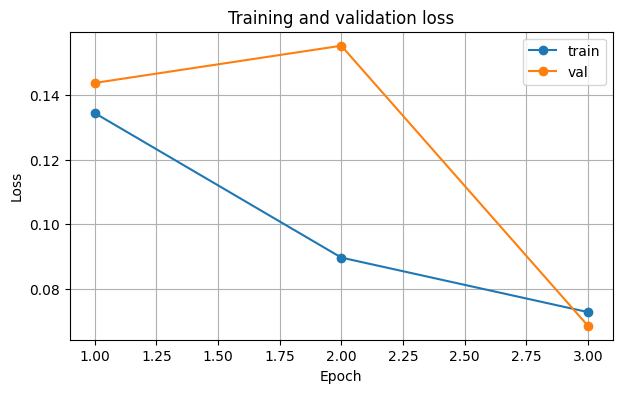

In [63]:
# Train for 3 epochs and plot epoch losses
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device', device)
model = model.to(device)
epochs = 3
train_losses = []
val_losses = []
for epoch in range(1, epochs+1):
    train_loss = train_one_epoch(model, train_loader, optim, criterion, device)
    val_loss = eval_one_epoch(model, train_loader, criterion, device)  # using train_loader as val for demo
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'Epoch {epoch}/{epochs} — train_loss: {train_loss:.6f}, val_loss: {val_loss:.6f}')

# Plot losses
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(range(1, epochs+1), train_losses, marker='o', label='train')
plt.plot(range(1, epochs+1), val_losses, marker='o', label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True)
plt.show()

Sample name: D47OR19ANJ
Video shape: (112, 112, 334) dtype: uint8
Predicted masks shape (H,W,T): (112, 112, 334)
Predicted masks shape (H,W,T): (112, 112, 334)


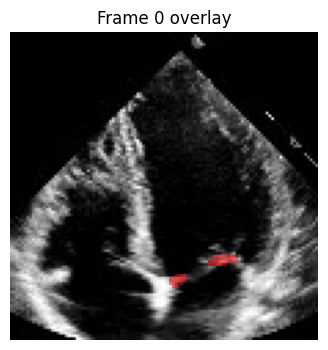

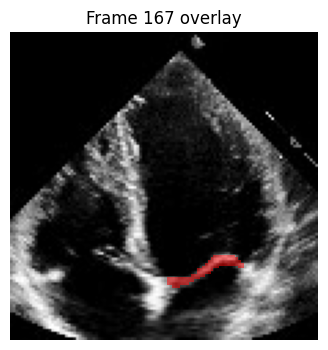

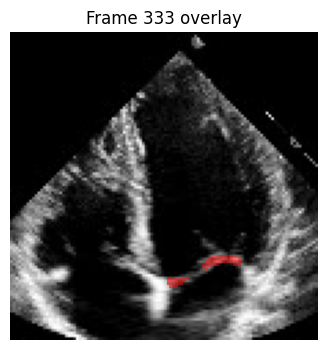

In [66]:
# Inference: compute segmentation masks for all frames of the first sample video
sample = data[0]
video = sample['video']  # expected shape (H, W, T)
print('Sample name:', sample.get('name'))
print('Video shape:', video.shape, 'dtype:', video.dtype)
# handle a couple of possible layouts robustly
if video.ndim == 3:
    H, W, T = video.shape

# Ensure model on device and in eval mode
model = model.to(device)
model.eval()

batch_sz = 16
masks_pred = []  # will collect (H,W) per frame
with torch.no_grad():
    for i in range(0, T, batch_sz):
        batch_frames = []
        for t in range(i, min(i+batch_sz, T)):
            frame = video[..., t]  # H,W
            img = frame.astype('float32') / 255.0
            if img.ndim == 2:
                img = img[..., None]  # H,W,1
            # to tensor C,H,W
            img_t = torch.from_numpy(img.transpose(2,0,1)).float()
            batch_frames.append(img_t)
        batch = torch.stack(batch_frames, dim=0).to(device)  # B,C,H,W
        logits = model(batch)
        if logits.shape[1] == 1:
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).long().squeeze(1).cpu().numpy()  # B,H,W
        else:
            preds = torch.argmax(torch.softmax(logits, dim=1), dim=1).cpu().numpy()  # B,H,W
        for p in preds:
            masks_pred.append(p)

# stack to (H,W,T) to mirror the original video layout
masks_pred = np.stack(masks_pred, axis=2)
print('Predicted masks shape (H,W,T):', masks_pred.shape)

# visualize a few frames with overlay
import matplotlib.pyplot as plt
for t in [0, max(0, T//2), T-1]:
    plt.figure(figsize=(4,4))
    plt.imshow(video[..., t], cmap='gray')
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    rgba[..., 0] = 1.0
    rgba[..., 3] = masks_pred[..., t].astype(float) * 0.5
    plt.imshow(rgba, interpolation='nearest')
    plt.title(f'Frame {t} overlay')
    plt.axis('off')
    plt.show()
